In [1]:
%cd ../

/home/eli/AnacondaProjects/surprisal_regression


In [2]:
import collections
import glob
import json
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import logsumexp

In [3]:
def logmeanexp(log_ws, axis=0):
    return logsumexp(log_ws, axis=axis) - np.log(log_ws.shape[axis])

In [4]:
ABLATIONS = [frozenset(), frozenset(["repetition"]), frozenset(["surprise"]), frozenset(["repetition", "surprise"])]
evidences = collections.defaultdict(lambda: {ablation: [] for ablation in ABLATIONS})

In [5]:
for session in glob.glob("TRAINING_SESSIONS*.json"):
    with open(session, "r") as f:
        session_evidences = json.load(f)
    for area in session_evidences:
        for (ablations, _, evidence) in session_evidences[area][:-1]:
            evidences[area][frozenset(ablations)].append(evidence)

In [6]:
comparisons = {area: 0.0 for area in evidences}

In [7]:
for area in evidences:
    comparisons[area] = logmeanexp(np.array(evidences[area][frozenset()] + evidences[area][frozenset(["repetition"])])) -\
                        logmeanexp(np.array(evidences[area][frozenset(["surprise"])] + evidences[area][frozenset(["repetition", "surprise"])]))

In [8]:
comparisons

{'PFC': -33.20972043814527,
 'FEF': 38.529296875,
 'MST': -2061.30859375,
 'MT': 2975.21875,
 'V4': 780.5781249999345,
 'V3': 1683.361328125,
 'V2': -6886.18359375,
 'V1': 1252.19140625}

<BarContainer object of 8 artists>

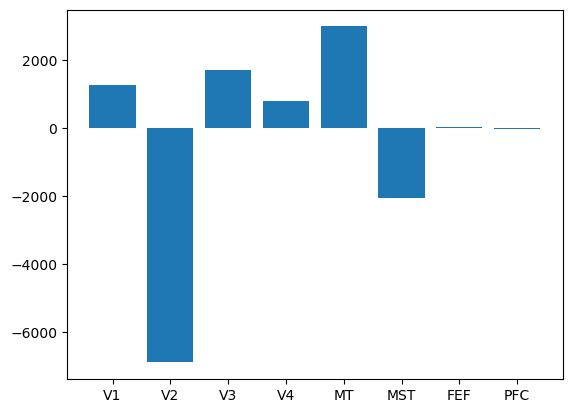

In [9]:
plt.bar(list(reversed(comparisons.keys())), list(reversed(comparisons.values())))